# Chapter 4: Reuters Multiclass Classification
## We’ll begin Reuters multiclass classification. As with IMDB, each observation is text, but now we predict one of 46 news topics.
### Section 1: Define the learning problem

Given a newswire, predict its assigned topic.

Each observation has one target class:

$$
y_i \in \{0,1,\ldots,45\}
$$

This is single-label multiclass classification: 46 possible classes,
with one assigned label per newswire in this dataset.

The dataset supplies each newswire as a variable-length sequence
of integer token IDs:

$$
r_i=[t_1,t_2,\ldots,t_{L_i}]
$$

As with IMDB, we will convert this sequence into a multi-hot vector:

$$
x_i=P(r_i)\in\{0,1\}^{10000}
$$

The model will output 46 topic probabilities.

The familiar pieces fit together this way:

Property	IMDB	Reuters
Observation	Movie review	Newswire
Target	Negative or positive	One of 46 topics
Input encoding	Multi-hot	Multi-hot
Output activation	Sigmoid	Softmax

Load the dataset:

In [13]:
import numpy as np
from tensorflow.keras.datasets import reuters

vocabulary_size = 10_000

(train_data, train_labels), (test_data, test_labels) = (
    reuters.load_data(num_words=vocabulary_size)
)

print("Training newswires:", len(train_data))
print("Test newswires:", len(test_data))
print("Training label shape:", train_labels.shape)
print("First 10 labels:", train_labels[:10])

Training newswires: 8982
Test newswires: 2246
Training label shape: (8982,)
First 10 labels: [ 3  4  3  4  4  4  4  3  3 16]


The default split should contain 8,982 training newswires and 2,246 test newswires.

Inspect the classes and one observation:

In [14]:
classes, counts = np.unique(train_labels, return_counts=True)

print("Number of training classes:", len(classes))
print("Smallest class ID:", classes.min())
print("Largest class ID:", classes.max())

print()
print("First newswire length:", len(train_data[0]))
print("First 20 token IDs:", train_data[0][:20])
print("First newswire label:", train_labels[0])

Number of training classes: 46
Smallest class ID: 0
Largest class ID: 45

First newswire length: 87
First 20 token IDs: [1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7]
First newswire label: 3


A topic ID is a category identifier. A label of 20 does not mean twice as much of something as a label of 10.

Look at the class counts:

In [15]:
for class_id, count in zip(classes, counts):
    print(f"Class {class_id:2d}: {count:4d} training examples")

Class  0:   55 training examples
Class  1:  432 training examples
Class  2:   74 training examples
Class  3: 3159 training examples
Class  4: 1949 training examples
Class  5:   17 training examples
Class  6:   48 training examples
Class  7:   16 training examples
Class  8:  139 training examples
Class  9:  101 training examples
Class 10:  124 training examples
Class 11:  390 training examples
Class 12:   49 training examples
Class 13:  172 training examples
Class 14:   26 training examples
Class 15:   20 training examples
Class 16:  444 training examples
Class 17:   39 training examples
Class 18:   66 training examples
Class 19:  549 training examples
Class 20:  269 training examples
Class 21:  100 training examples
Class 22:   15 training examples
Class 23:   41 training examples
Class 24:   62 training examples
Class 25:   92 training examples
Class 26:   24 training examples
Class 27:   15 training examples
Class 28:   48 training examples
Class 29:   19 training examples
Class 30: 

Notice whether some topics have many more examples than others. That is class imbalance: overall accuracy can hide poor performance on less frequent topics.

For your handwritten notes:

$$ \underbrace{r_i}_{\text{token sequence}} \quad\longrightarrow\quad \underbrace{x_i}_{\text{10,000 input features}} \quad\longrightarrow\quad \underbrace{\hat{y}_i}_{\text{46 topic probabilities}} $$

The 10,000 input features and 46 output classes describe different things. Vocabulary size determines the input representation; the topic labels determine the output categories.

Next, we’ll vectorize the newswires and encode their labels as 46-element one-hot vectors—distinguishing multi-hot inputs from one-hot targets.

## Section 2: Encode inputs and targets

Each newswire becomes a multi-hot input vector:

$$
x_i=P(r_i)\in\{0,1\}^{10000}
$$

Many positions may contain 1 because many tokens occur in a newswire.

Its integer topic label is:

$$
y_i\in\{0,1,\ldots,45\}
$$

We encode that label as a one-hot target vector:

$$
t_i\in\{0,1\}^{46}
$$

For position $k$:

$$
t_{i,k}=
\begin{cases}
1 & \text{if }k=y_i\\
0 & \text{otherwise}
\end{cases}
$$

Exactly one target position contains 1:

$$
\sum_{k=0}^{45}t_{i,k}=1
$$

### First, vectorize the newswires. Define the function in this notebook too; it should not depend on running your IMDB notebook.

In [16]:
import numpy as np

def vectorize_sequences(sequences, dimension=10_000):
    results = np.zeros(
        (len(sequences), dimension),
        dtype="float32"
    )

    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0

    return results

x_train = vectorize_sequences(train_data, vocabulary_size)
x_test = vectorize_sequences(test_data, vocabulary_size)

print("Training inputs:", x_train.shape)
print("Test inputs:", x_test.shape)

Training inputs: (8982, 10000)
Test inputs: (2246, 10000)


Now encode the targets. For a small example with five classes, class 3 becomes:

$$ 3\longrightarrow[0,0,0,1,0] $$

The 1 goes in position 3 because positions start at zero.

Add this Code cell:

In [17]:
from tensorflow.keras.utils import to_categorical

number_of_classes = 46

y_train = to_categorical(
    train_labels,
    num_classes=number_of_classes
).astype("float32")

y_test = to_categorical(
    test_labels,
    num_classes=number_of_classes
).astype("float32")

print("Training targets:", y_train.shape)
print("Test targets:", y_test.shape)

Training targets: (8982, 46)
Test targets: (2246, 46)


Here, Python’s y_train stores the one-hot vectors we called \(t_i\) in the mathematics. The original integer labels remain in train_labels.

Inspect one target to verify the mapping:

In [18]:
print("Original topic ID:", train_labels[0])
print("One-hot target:")
print(y_train[0])

print("Sum of target entries:", y_train[0].sum())
print("Recovered topic ID:", np.argmax(y_train[0]))

Original topic ID: 3
One-hot target:
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Sum of target entries: 1.0
Recovered topic ID: 3


The recovered topic ID should equal the original label.
`argmax` returns the index of the largest entry—the single 1 in this target.

| Representation | Length per observation | Meaning of a 1 |
| --- | --- | --- |
| Multi-hot input | 10,000 | This token occurs in the newswire |
| One-hot target | 46 | This is the assigned topic |

### For your handwritten notes

$x_i$ is the numerical input the model receives.

$t_i$ is the correct topic encoded as a one-hot target.

For example, topic 3 has a 1 in the fourth position because indexing starts at 0:

$$
t_i = [0,\;0,\;0,\;1,\;0,\;\ldots,\;0]
$$

This target has 46 entries altogether.

### Network architecture

$$
10{,}000 \rightarrow 64 \rightarrow 64 \rightarrow 46
$$

The network receives 10,000 input features and produces 46 topic probabilities.
Its two hidden layers each contain 64 neurons.

We use softmax for the output and categorical cross-entropy for the loss.

## Section 3: Build the Reuters network

Our architecture is:

$$
10{,}000 \rightarrow 64 \rightarrow 64 \rightarrow 46
$$

For one newswire, the forward pass is:

$$
h_1 = \operatorname{ReLU}(W_1x + b_1)
$$

$$
h_2 = \operatorname{ReLU}(W_2h_1 + b_2)
$$

$$
\hat{y} = \operatorname{softmax}(W_3h_2 + b_3)
$$

Using column vectors in our handwritten mathematics:

- $x$ contains 10,000 input features.
- $h_1$ contains 64 learned activations.
- $h_2$ contains 64 learned activations.
- $\hat{y}$ contains 46 predicted topic probabilities.

Softmax makes the output probabilities sum to 1.

The input size comes from our vocabulary representation.
The output size comes from the number of topic classes.
The two hidden layers of 64 neurons are an architecture choice.

Building the network initializes its weights and biases.
Learning begins later when we train it.

In [19]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    keras.Input(shape=(10_000,)),
    layers.Dense(64, activation="relu", name="hidden_1"),
    layers.Dense(64, activation="relu", name="hidden_2"),
    layers.Dense(46, activation="softmax", name="topic")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ topic (Dense)                   │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 647,214 (2.47 MB)

 Trainable params: 647,214 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

None represents a flexible batch size. Each Dense layer has inputs × neurons + one bias per neuron parameters.
Once this runs, model exists in your notebook’s current session. After this comes compiling the network, then the validation split and training.

## Section 4: Compile the network

### Next is Section 4: Compile the Reuters network. This sets the loss function, optimizer, and reporting metric before training.

We configure three components:

| Component | Choice | Purpose |
| --- | --- | --- |
| Loss | Categorical cross-entropy | Measure prediction error |
| Optimizer | RMSprop | Use gradients to adjust weights and biases |
| Metric | Accuracy | Report the fraction of correctly classified newswires |

For one newswire, categorical cross-entropy is:

$$
L_i = -\sum_{k=0}^{45} t_{i,k}\log(\hat{y}_{i,k})
$$

Here:

- $t_{i,k}$ is the target entry for topic $k$: either 0 or 1.
- $\hat{y}_{i,k}$ is the model's predicted probability for topic $k$.

Because the target is one-hot, only the correct topic contributes to the loss.

For a newswire whose correct topic is 3:

$$
L_i = -\log(\hat{y}_{i,3})
$$

Assigning a higher probability to the correct topic produces a lower loss.

For example:

- Correct-topic probability 0.90 gives loss approximately 0.105.
- Correct-topic probability 0.10 gives loss approximately 2.303.

Accuracy checks whether the highest-probability topic matches the target.
The optimizer uses gradients of the loss to learn.

Compiling configures training. It does not train the network.

In [20]:
model.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Reuters model compiled and ready for training.")

Reuters model compiled and ready for training.


### Connection to your earlier notebooks

| Example | Target representation | Loss |
| --- | --- | --- |
| MNIST | Integer digit label | Sparse categorical cross-entropy |
| IMDB | Binary label, 0 or 1 | Binary cross-entropy |
| Reuters | One-hot topic vector | Categorical cross-entropy |

Reuters uses categorical cross-entropy because we encoded its targets
as one-hot vectors. Integer topic labels would instead work with
sparse categorical cross-entropy.

Next, we will reserve the validation set before training.

## Section 5: Reserve a validation set
### Your Reuters model is compiled. Section 5 reserves a validation set so we can monitor how well it handles newswires it isn’t learning from.

We divide our 8,982 training newswires into two groups:

| Group | Observations | Purpose |
| --- | ---: | --- |
| Training subset | 7,982 | Learn weights and biases |
| Validation set | 1,000 | Monitor performance and guide training duration |

The separate test set stays reserved for final evaluation.

Each newswire has 10,000 input features and a one-hot target with 46 entries.

Our validation tensors therefore have these shapes:

$$
X_{\mathrm{val}} \in \{0,1\}^{1000 \times 10000}
$$

$$
Y_{\mathrm{val}} \in \{0,1\}^{1000 \times 46}
$$

Each input row must remain paired with its corresponding target row.

Validation computes loss and accuracy without updating weights or biases.

In [21]:
validation_size = 1_000

# First 1,000 observations: validation
x_val = x_train[:validation_size]
y_val = y_train[:validation_size]

# Remaining observations: training
partial_x_train = x_train[validation_size:]
partial_y_train = y_train[validation_size:]

print("Training inputs:", partial_x_train.shape)
print("Training targets:", partial_y_train.shape)
print("Validation inputs:", x_val.shape)
print("Validation targets:", y_val.shape)

Training inputs: (7982, 10000)
Training targets: (7982, 46)
Validation inputs: (1000, 10000)
Validation targets: (1000, 46)


In Python, [:1000] selects rows 0 through 999, and [1000:] selects the remaining rows. Applying the same slices to inputs and targets preserves their pairing.
Next, we’ll train the network and record its training and validation results.

## Section 6: Train the network

### Next is Section 6: Train the Reuters network. We’ll train for 20 epochs and record validation performance so we can examine when overfitting begins.

An epoch is one complete pass through the 7,982 training observations.

We use batches of up to 512 newswires. For each batch, the network:

1. Computes 46 topic probabilities for each newswire.
2. Calculates categorical cross-entropy.
3. Computes gradients through backpropagation.
4. Uses RMSprop to update the weights and biases.

For a batch B, the mean loss is:

$$
L_B =
-\frac{1}{|B|}
\sum_{i \in B}
\sum_{k=0}^{45}
t_{i,k}\log(\hat{y}_{i,k})
$$

Here, $|B|$ is the number of newswires in the batch.

There are 16 training batches per epoch:
15 batches of 512 observations and one batch of 302.

After each epoch, the model evaluates the 1,000 validation observations
without updating its parameters.

We record four measurements:

| Measurement | Meaning |
| --- | --- |
| loss | Training cross-entropy |
| accuracy | Training classification accuracy |
| val_loss | Validation cross-entropy |
| val_accuracy | Validation classification accuracy |

Twenty epochs is an initial experiment.
We will use the validation results to choose a suitable training duration.

In [22]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    shuffle=True,
    verbose=2
)

Epoch 1/20
16/16 - 1s - 85ms/step - accuracy: 0.4985 - loss: 2.8232 - val_accuracy: 0.6180 - val_loss: 1.9175
Epoch 2/20
16/16 - 0s - 16ms/step - accuracy: 0.6711 - loss: 1.5901 - val_accuracy: 0.6880 - val_loss: 1.3976
Epoch 3/20
16/16 - 0s - 14ms/step - accuracy: 0.7363 - loss: 1.1986 - val_accuracy: 0.7360 - val_loss: 1.2149
Epoch 4/20
16/16 - 0s - 14ms/step - accuracy: 0.7904 - loss: 0.9791 - val_accuracy: 0.7490 - val_loss: 1.0960
Epoch 5/20
16/16 - 0s - 14ms/step - accuracy: 0.8269 - loss: 0.8132 - val_accuracy: 0.7620 - val_loss: 1.0308
Epoch 6/20
16/16 - 0s - 16ms/step - accuracy: 0.8523 - loss: 0.6872 - val_accuracy: 0.7950 - val_loss: 0.9545
Epoch 7/20
16/16 - 0s - 16ms/step - accuracy: 0.8789 - loss: 0.5688 - val_accuracy: 0.8010 - val_loss: 0.9178
Epoch 8/20
16/16 - 0s - 14ms/step - accuracy: 0.8984 - loss: 0.4788 - val_accuracy: 0.8080 - val_loss: 0.8909
Epoch 9/20
16/16 - 0s - 13ms/step - accuracy: 0.9163 - loss: 0.4025 - val_accuracy: 0.8140 - val_loss: 0.8697
Epoch 10/2

You should see one results line per epoch, containing loss, accuracy, val_loss, and val_accuracy. Your exact numbers will vary.
Run this training cell once for this experiment. Running it again continues training from the current weights; it does not start over.
After it finishes, run this separate Code cell:

In [23]:
print("Recorded measurements:", list(history.history.keys()))
print("Epochs completed:", len(history.history["loss"]))

Recorded measurements: ['accuracy', 'loss', 'val_accuracy', 'val_loss']
Epochs completed: 20


The epoch count should be 20. Next, we’ll plot the recorded losses and compare learning on training data with performance on validation data.

## Section 7: Compare training and validation loss

Next is Section 7: Plot training and validation loss. The 20 epoch results are stored in history.history; this step helps you see when validation performance stops improving.

Training loss measures error on newswires used to update the model.

Validation loss measures error on the 1,000 newswires held aside from
those updates.

If training loss keeps falling while validation loss starts rising,
the model is beginning to overfit. We will use the epoch with the
lowest validation loss as a guide for our final training run.

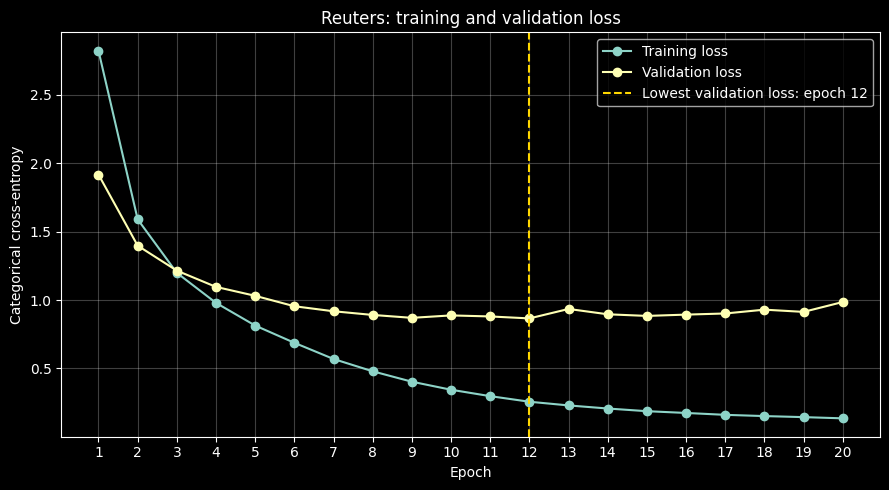

Epoch with lowest validation loss: 12
Lowest validation loss: 0.8655


In [24]:
import numpy as np
import matplotlib.pyplot as plt

training_loss = history.history["loss"]
validation_loss = history.history["val_loss"]
epochs = np.arange(1, len(training_loss) + 1)

best_epoch = int(np.argmin(validation_loss)) + 1

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(epochs, training_loss, "o-", label="Training loss")
    ax.plot(epochs, validation_loss, "o-", label="Validation loss")
    ax.axvline(best_epoch, color="gold", linestyle="--",
               label=f"Lowest validation loss: epoch {best_epoch}")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Categorical cross-entropy")
    ax.set_title("Reuters: training and validation loss")
    ax.set_xticks(epochs)
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

print("Epoch with lowest validation loss:", best_epoch)
print("Lowest validation loss:", round(validation_loss[best_epoch - 1], 4))

The dark plotting style should be easier on your eyes. The dashed line identifies the best epoch in this particular run; your number may differ from the book’s. best_epoch - 1 converts the human-readable epoch number back to Python’s zero-based list index. This cell only reads the recorded results—it does not train the model again.

## Section 8: Compare training and validation accuracy

Next is Section 8: Compare training and validation accuracy. You’ve already found the epoch with the lowest validation loss. This plot shows whether classification accuracy tells a similar story.

Accuracy is the fraction of newswires assigned the correct topic.

Training accuracy is measured on examples used to update the model.
Validation accuracy is measured on the 1,000 reserved examples.

If training accuracy rises while validation accuracy levels off or falls,
additional training may be fitting the training examples too closely.

We will still use the lowest validation loss to choose our training
duration. Accuracy gives us another view of the same experiment.

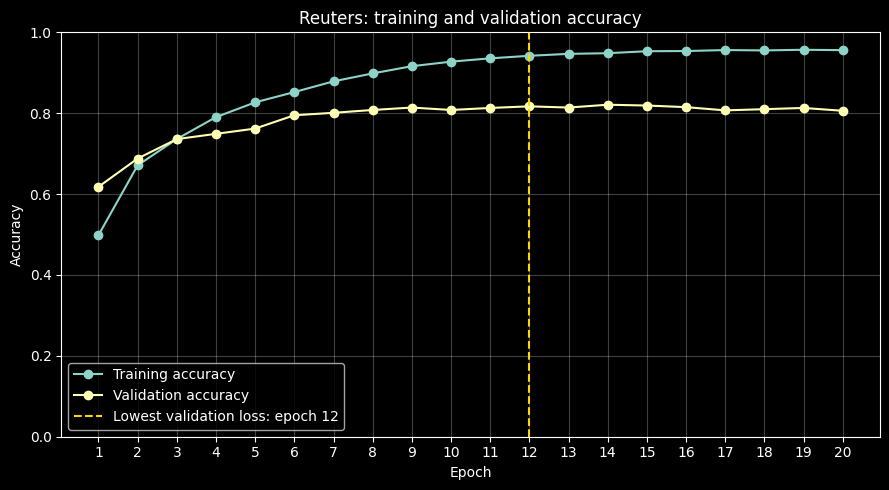

Validation accuracy at the selected epoch: 0.817
Highest validation accuracy: 0.821


In [25]:
training_accuracy = history.history["accuracy"]
validation_accuracy = history.history["val_accuracy"]
epochs = np.arange(1, len(training_accuracy) + 1)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(epochs, training_accuracy, "o-", label="Training accuracy")
    ax.plot(epochs, validation_accuracy, "o-", label="Validation accuracy")
    ax.axvline(best_epoch, color="gold", linestyle="--",
               label=f"Lowest validation loss: epoch {best_epoch}")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title("Reuters: training and validation accuracy")
    ax.set_xticks(epochs)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

print("Validation accuracy at the selected epoch:",
      round(validation_accuracy[best_epoch - 1], 4))
print("Highest validation accuracy:",
      round(max(validation_accuracy), 4))

The epoch with highest validation accuracy may differ from the one with lowest validation loss. Accuracy only checks whether the top topic is correct; cross-entropy also responds to how much probability the model assigns to the correct topic.
Next, we’ll use the selected training duration to build a fresh model and train it on all 8,982 training newswires.

## Section 9: Train a final model on all training data

Next is Section 9: Train the final Reuters model. We’ll create a fresh network with the same architecture and train it on all 8,982 training newswires for the number of epochs chosen from validation loss.

The validation experiment helped us choose `best_epoch`.

We now create a new model with the same architecture and train it
on all 8,982 original training newswires:

$$
X_{\mathrm{train}} \in \{0,1\}^{8982 \times 10000}
$$

$$
Y_{\mathrm{train}} \in \{0,1\}^{8982 \times 46}
$$

This includes the 1,000 newswires previously reserved for validation.
The separate test set is still untouched.

`history` records how the earlier model performed. It does not restore
that model's weights to the selected epoch, so we start with a fresh model.

In [26]:
final_model = keras.Sequential([
    keras.Input(shape=(10_000,)),
    layers.Dense(64, activation="relu", name="hidden_1"),
    layers.Dense(64, activation="relu", name="hidden_2"),
    layers.Dense(46, activation="softmax", name="topic")
])

final_model.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

final_history = final_model.fit(
    x_train,
    y_train,
    epochs=best_epoch,
    batch_size=512,
    verbose=2
)

print("Training observations:", x_train.shape[0])
print("Epochs completed:", len(final_history.history["loss"]))

Epoch 1/12
18/18 - 1s - 43ms/step - accuracy: 0.4827 - loss: 2.7026
Epoch 2/12
18/18 - 0s - 11ms/step - accuracy: 0.6798 - loss: 1.5116
Epoch 3/12
18/18 - 0s - 11ms/step - accuracy: 0.7509 - loss: 1.1515
Epoch 4/12
18/18 - 0s - 10ms/step - accuracy: 0.7997 - loss: 0.9335
Epoch 5/12
18/18 - 0s - 10ms/step - accuracy: 0.8343 - loss: 0.7713
Epoch 6/12
18/18 - 0s - 11ms/step - accuracy: 0.8673 - loss: 0.6353
Epoch 7/12
18/18 - 0s - 12ms/step - accuracy: 0.8916 - loss: 0.5241
Epoch 8/12
18/18 - 0s - 11ms/step - accuracy: 0.9070 - loss: 0.4373
Epoch 9/12
18/18 - 0s - 10ms/step - accuracy: 0.9200 - loss: 0.3737
Epoch 10/12
18/18 - 0s - 12ms/step - accuracy: 0.9312 - loss: 0.3168
Epoch 11/12
18/18 - 0s - 13ms/step - accuracy: 0.9389 - loss: 0.2773
Epoch 12/12
18/18 - 0s - 12ms/step - accuracy: 0.9422 - loss: 0.2425
Training observations: 8982
Epochs completed: 12


You should see Training observations: 8982. The epoch count should equal the best_epoch printed in Section 7.
The new model starts with newly initialized weights, so its results need not exactly match the earlier run. Next, we’ll evaluate it once on the held-out Reuters test set.

## Section 10: Evaluate on the test set

### Next is Section 10: Evaluate the final Reuters model on the 2,246 test

The test set contains newswires the model did not use to update
its weights or choose its training duration.

$$
X_{\mathrm{test}} \in \{0,1\}^{2246 \times 10000}
$$

$$
Y_{\mathrm{test}} \in \{0,1\}^{2246 \times 46}
$$

Test loss measures categorical cross-entropy.
Test accuracy measures the fraction assigned the correct topic.

In [27]:
test_loss, test_accuracy = final_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test loss: 1.0066
Test accuracy: 78.09%


For example, an accuracy displayed as 80.00% would mean the model assigned the correct topic to about 80% of test newswires. Your actual result comes from your run.
Keep the two outputs distinct: accuracy tells you how often the top choice was right; loss also reflects the probabilities assigned to the correct topics. Next, we’ll inspect the model’s 46 probabilities for an individual newswire.

## Section 11: Inspect one newswire prediction

Next is Section 11: Inspect one prediction. The model produces 46 probabilities for a newswire, one per topic.

For one input $x_i$, the softmax layer returns:

$$
\hat{y}_i =
[\hat{y}_{i,0}, \hat{y}_{i,1}, \ldots, \hat{y}_{i,45}]
$$

Each entry is a predicted topic probability, and all 46 entries
sum to approximately 1.

The predicted topic is the position with the highest probability:

$$
\hat{k}_i = \operatorname*{argmax}_k \hat{y}_{i,k}
$$

In [28]:
newswire_index = 0

# Keep the batch dimension: (1, 10000)
one_newswire = x_test[newswire_index:newswire_index + 1]

probabilities = final_model.predict(one_newswire, verbose=0)[0]
predicted_topic = int(np.argmax(probabilities))
actual_topic = int(test_labels[newswire_index])

print("Input shape:", one_newswire.shape)
print("Probability vector shape:", probabilities.shape)
print("Sum of probabilities:", round(float(probabilities.sum()), 6))
print("Predicted topic ID:", predicted_topic)
print("Actual topic ID:", actual_topic)
print("Probability assigned to predicted topic:",
      round(float(probabilities[predicted_topic]), 4))

top_five = np.argsort(probabilities)[-5:][::-1]

print("\nFive most probable topic IDs:")
for topic_id in top_five:
    print(f"Topic {topic_id:2d}: {probabilities[topic_id]:.2%}")

Input shape: (1, 10000)
Probability vector shape: (46,)
Sum of probabilities: 1.0
Predicted topic ID: 3
Actual topic ID: 3
Probability assigned to predicted topic: 0.9981

Five most probable topic IDs:
Topic  3: 99.81%
Topic  4: 0.08%
Topic 16: 0.07%
Topic 39: 0.01%
Topic 21: 0.01%


The expected shapes are (1, 10000) for the input batch and (46,) for its probability vector. The predicted and actual topic IDs might differ for this particular newswire; that would give us an example to investigate.
Next, we can attach topic names to those IDs and decode the newswire text so the prediction is easier to interpret.

## Section 12: Read the predicted topic and newswire

Next is Section 12: Put names and words beside the prediction. We’ll use the original token sequence to reconstruct a readable version of the newswire. Keras provides a word index and, in current versions, a list of topic names.

The model received $x_i$, a 10,000-entry multi-hot vector.
That vector records which words occur but loses their order.

The original token sequence, `test_data[i]`, still has word order.
We can use the Reuters word index to turn its token IDs back into
an approximate readable newswire.

We compare the predicted topic with the newswire's actual topic.

In [29]:
from tensorflow.keras.datasets import reuters

newswire_index = 0

# Reproduce the prediction so this cell has all the values it needs.
probabilities = final_model.predict(
    x_test[newswire_index:newswire_index + 1],
    verbose=0
)[0]

predicted_topic = int(np.argmax(probabilities))
actual_topic = int(test_labels[newswire_index])

# Topic names are available in newer Keras versions.
if hasattr(reuters, "get_label_names"):
    topic_names = reuters.get_label_names()
    def topic_name(topic_id):
        return topic_names[topic_id]
else:
    def topic_name(topic_id):
        return f"topic {topic_id}"

print(f"Predicted: {predicted_topic} — {topic_name(predicted_topic)}")
print(f"Actual:    {actual_topic} — {topic_name(actual_topic)}")
print(f"Predicted-topic probability: {probabilities[predicted_topic]:.2%}")

print("\nFive most probable topics:")
for topic_id in np.argsort(probabilities)[-5:][::-1]:
    print(f"{topic_id:2d} — {topic_name(topic_id)}: "
          f"{probabilities[topic_id]:.2%}")

word_index = reuters.get_word_index()
id_to_word = {word_id + 3: word for word, word_id in word_index.items()}
id_to_word.update({
    0: "<PAD>",
    1: "<START>",
    2: "<UNKNOWN>"
})

decoded_newswire = " ".join(
    id_to_word.get(token_id, "<UNKNOWN>")
    for token_id in test_data[newswire_index]
)

print("\nDecoded newswire:\n")
print(decoded_newswire)

Predicted: 3 — earn
Actual:    3 — earn
Predicted-topic probability: 99.81%

Five most probable topics:
 3 — earn: 99.81%
 4 — acq: 0.08%
16 — crude: 0.07%
39 — pet-chem: 0.01%
21 — gnp: 0.01%
550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Decoded newswire:

<START> the great atlantic and pacific tea co said its three year 345 mln dlr capital program will be be substantially increased to <UNKNOWN> growth and expansion plans for <UNKNOWN> inc and <UNKNOWN> inc over the next two years a and p said the acquisition of <UNKNOWN> in august 1986 and <UNKNOWN> in december helped us achieve better than expected results in the fourth quarter ended february 28 its net income from continuing operations jumped 52 6 pct to 20 7 mln dlrs or 55 cts a share in the latest quarter as sales increased 48 3 pct to 1 58 billion dlrs a and p gave no details on the expanded capital program but it did say it completed the first year of the program during 1986 a and p is 52 4 pct owned by lt <UNKNOWN> <UNKNOWN>

The + 3 matters: Reuters reserves token IDs 0, 1, and 2 for padding, start, and unknown tokens. The decoded text may contain <UNKNOWN> where words fell outside the 10,000-word vocabulary. keras.io
Look at the predicted and actual topic names alongside the words in the article. That gives us a concrete way to examine what the classifier got right or wrong.

## Section 13: Examine a classification error

### Next is Section 13: Examine a mistake. We’ll find a test newswire the model classified incorrectly and compare its top two topic probabilities with the actual topic.

Overall accuracy tells us how often the model is right.
An individual error helps us see what kind of confusion occurred.

For a misclassified newswire, inspect:

1. Its actual topic.
2. The model's predicted topic.
3. The probabilities assigned to both topics.
4. The words in the original newswire.

A softmax probability describes the model's output for this
newswire; it is not necessarily a calibrated measure of certainty.

Then add and run this Code cell. It uses topic_name and id_to_word

In [30]:
all_probabilities = final_model.predict(
    x_test,
    batch_size=512,
    verbose=0
)

predicted_topics = np.argmax(all_probabilities, axis=1)
error_indices = np.flatnonzero(predicted_topics != test_labels)

print(f"Misclassified test newswires: {len(error_indices)} of {len(test_labels)}")

if len(error_indices) > 0:
    error_index = int(error_indices[0])
    actual_topic = int(test_labels[error_index])
    predicted_topic = int(predicted_topics[error_index])
    probabilities = all_probabilities[error_index]

    print(f"\nTest newswire index: {error_index}")
    print(f"Actual:    {actual_topic} — {topic_name(actual_topic)}")
    print(f"Predicted: {predicted_topic} — {topic_name(predicted_topic)}")
    print(f"Probability for actual topic: "
          f"{probabilities[actual_topic]:.2%}")
    print(f"Probability for predicted topic: "
          f"{probabilities[predicted_topic]:.2%}")

    decoded_newswire = " ".join(
        id_to_word.get(token_id, "<UNKNOWN>")
        for token_id in test_data[error_index]
    )

    print("\nDecoded newswire:\n")
    print(decoded_newswire)

Misclassified test newswires: 492 of 2246

Test newswire index: 3
Actual:    4 — acq
Predicted: 16 — crude
Probability for actual topic: 4.15%
Probability for predicted topic: 85.89%

Decoded newswire:

<START> <UNKNOWN> <UNKNOWN> oil and gas partnership said it completed the sale of interests in two major oil and gas fields to lt energy assets international corp for 21 mln dlrs the company said it sold about one half of its 50 pct interest in the oak hill and north <UNKNOWN> fields its two largest producing properties it said it used about 20 mln dlrs of the proceeds to <UNKNOWN> principal on its senior secured notes semi annual principal payments on the remaining 40 mln dlrs of notes have been satisfied until december 1988 as a result it said the company said the note agreements were amended to reflect an easing of some financial covenants and an increase of interest to 13 5 pct from 13 0 pct until december 1990 it said the <UNKNOWN> exercise price for 1 125 000 warrants was also red

Notice that this uses test_data[error_index] to read the words, while the model predicted from x_test[error_index], the multi-hot representation of that same newswire. Those two arrays refer to the same observation in different forms.
Next, we’ll summarize what changed across MNIST, IMDB, and Reuters before starting the housing regression example.

## Section 14: MNIST, IMDB, and Reuters compared

Next is Section 14: Compare the three classification problems. This is a useful page for your handwritten notes because it connects the data shape to the model’s output and loss.

| Example | Raw observation | Numerical input | Target | Model output | Loss |
| --- | --- | --- | --- | --- | --- |
| MNIST | Handwritten digit image | 784 scaled pixel values | Integer class, 0–9 | 10 digit probabilities | Sparse categorical cross-entropy |
| IMDB | Movie review as token IDs | 10,000-entry multi-hot vector | Binary label, 0 or 1 | One positive-review probability | Binary cross-entropy |
| Reuters | Newswire as token IDs | 10,000-entry multi-hot vector | 46-entry one-hot vector | 46 topic probabilities | Categorical cross-entropy |

### The shared blueprint

For every example, we made these choices in order:

1. Define what one observation is and what we want to predict.
2. Convert the observation into a numerical input, $x_i = P(r_i)$.
3. Choose an output that matches the prediction task.
4. Encode the correct answer in a compatible target.
5. Choose a loss that compares that output with the target.
6. Train, inspect validation performance, and evaluate on a reserved test set.

The input width and output width answer different questions:

- **Input width:** How did we represent one observation numerically?
- **Output width:** What must the model predict?

MNIST and Reuters both predict one of several classes, but we encoded
their targets differently. MNIST used integer labels with sparse
categorical cross-entropy. Reuters used one-hot vectors with
categorical cross-entropy.

IMDB has two classes, so one sigmoid output represents the probability
of the positive class.

### One limitation of our text representation

For IMDB and Reuters, a multi-hot input records whether a token appears.
It loses word order and repeated counts. Later sequence models will
let us preserve that information.

That completes the Reuters classification notebook’s main experiment. We have now compared binary classification with two ways of representing multiclass targets. Next in Chapter 4 is housing price regression: its output will be a single number representing a predicted price, rather than a class probability.